**Set environment**

In [1]:
import numpy  as np
import pandas as pd
import pickle
import os

from Bio import SeqIO

import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
%run ../run_config_project.py
show_env()

BASE DIRECTORY (FD_BASE): /hpc/group/igvf/kk319
REPO DIRECTORY (FD_REPO): /hpc/group/igvf/kk319/repo
WORK DIRECTORY (FD_WORK): /hpc/group/igvf/kk319/work
DATA DIRECTORY (FD_DATA): /hpc/group/igvf/kk319/data


You are working with      IGVF BlueSTARR
PATH OF PROJECT (FD_PRJ): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR
PROJECT RESULTS (FD_RES): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/results
PROJECT SCRIPTS (FD_EXE): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/scripts
PROJECT DATA    (FD_DAT): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/data
PROJECT NOTE    (FD_NBK): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/notebooks
PROJECT DOCS    (FD_DOC): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/docs
PROJECT LOG     (FD_LOG): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/log
PROJECT REF     (FD_REF): /hpc/group/igvf/kk319/repo/Proj_IGVF_BlueSTARR/references



## Import data

In [3]:
txt_fdiry = os.path.join(FD_RES, "analysis_variant_motif_richard", "batches_dev")
txt_fpath = f"{txt_fdiry}/motifscan_variant_closed_gof_bluestarr_flank35_dev1000_delta_score.pkl"

with open(txt_fpath, "rb") as file:
    dct_motifscan_delta = pickle.load(file)

In [4]:
print(len(dct_motifscan_delta))  # should be 1000 sequences
seq0 = next(iter(dct_motifscan_delta))
motif0 = next(iter(dct_motifscan_delta[seq0]))
print("Example:", seq0, "→", motif0)
print("Keys:", dct_motifscan_delta[seq0][motif0].keys())
print("Array shape (merge):", dct_motifscan_delta[seq0][motif0]["merge"].shape)

1000
Example: chr9:135685432:G:G:C → MA0002.3 Runx1
Keys: dict_keys(['forward', 'reverse', 'merge'])
Array shape (merge): (63,)


In [5]:
motif_all = list(next(iter(dct_motifscan_delta.values())).keys())

# filter for AP1-related motifs
motif_ap1 = [m for m in motif_all if any(x in m.upper() for x in ["AP1", "FOS", "JUN"])]
print("AP1-related motifs found:")
for m in motif_ap1:
    print("  ", m)

AP1-related motifs found:
   MA0099.4 FOS::JUN
   MA0462.3 BATF::JUN
   MA0476.2 FOS
   MA0477.3 FOSL1
   MA0478.2 FOSL2
   MA0488.2 JUN
   MA0489.3 Jun
   MA0490.3 JUNB
   MA0491.3 JUND
   MA0492.2 JUND
   MA0597.3 THAP1
   MA1126.2 FOS::JUN
   MA1127.1 FOSB::JUN
   MA1128.2 FOSL1::JUN
   MA1129.1 FOSL1::JUN
   MA1130.2 FOSL2::JUN
   MA1131.2 FOSL2::JUN
   MA1132.2 JUN::JUNB
   MA1133.2 JUN::JUNB
   MA1134.2 FOS::JUNB
   MA1135.2 FOSB::JUNB
   MA1136.1 FOSB::JUNB
   MA1137.2 FOSL1::JUNB
   MA1138.2 FOSL2::JUNB
   MA1139.2 FOSL2::JUNB
   MA1140.3 JUNB
   MA1141.2 FOS::JUND
   MA1142.2 FOSL1::JUND
   MA1143.2 FOSL1::JUND
   MA1144.2 FOSL2::JUND
   MA1145.2 FOSL2::JUND
   MA1573.2 Thap11
   MA1951.2 FOS


In [6]:
motif_all = list(next(iter(dct_motifscan_delta.values())).keys())

# filter for AP1-related motifs
motif_ap1 = [m for m in motif_all if any(x in m.upper() for x in ["MYC", "MYCN"])]
print("MYC-related motifs found:")
for m in motif_ap1:
    print("  ", m)

MYC-related motifs found:
   MA0059.2 MAX::MYC
   MA0104.5 MYCN
   MA0147.4 MYC


In [8]:
txt_motif_target = "MA0099.4 FOS::JUN"

mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["merge"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx)

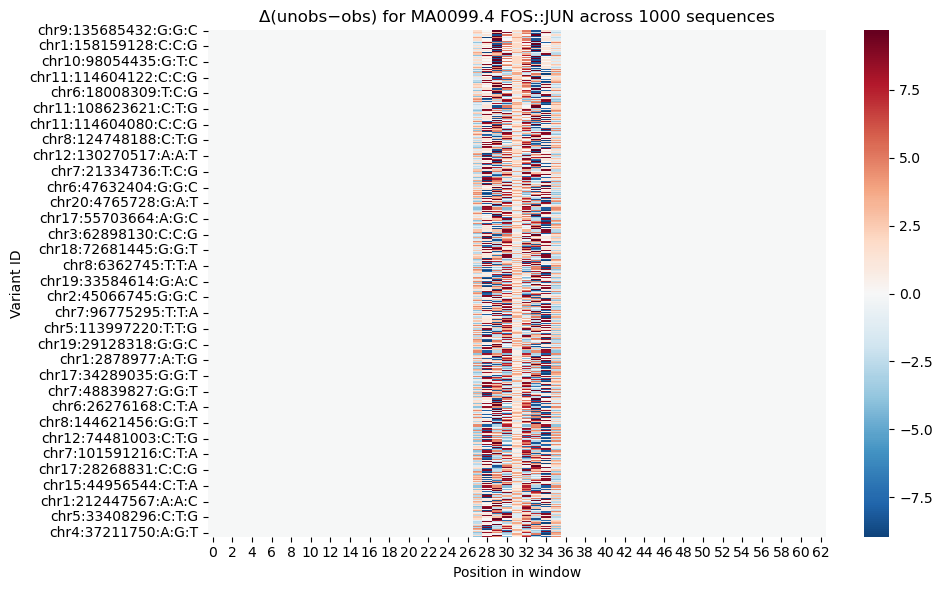

In [10]:
plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs−obs) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position in window")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

In [11]:
num_motif_window = 63
num_half_length  = num_motif_window // 2  # 31

vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


In [12]:
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

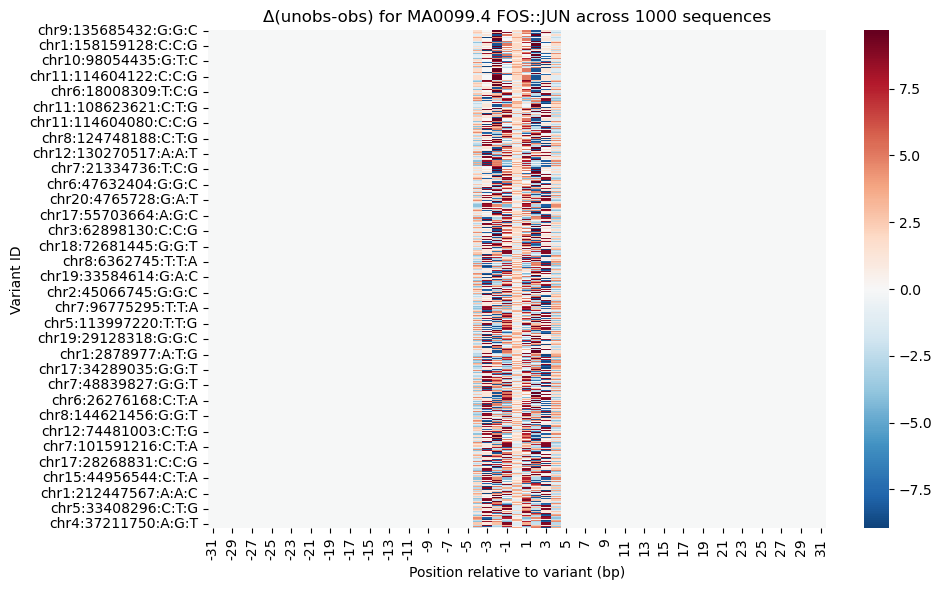

In [14]:
plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


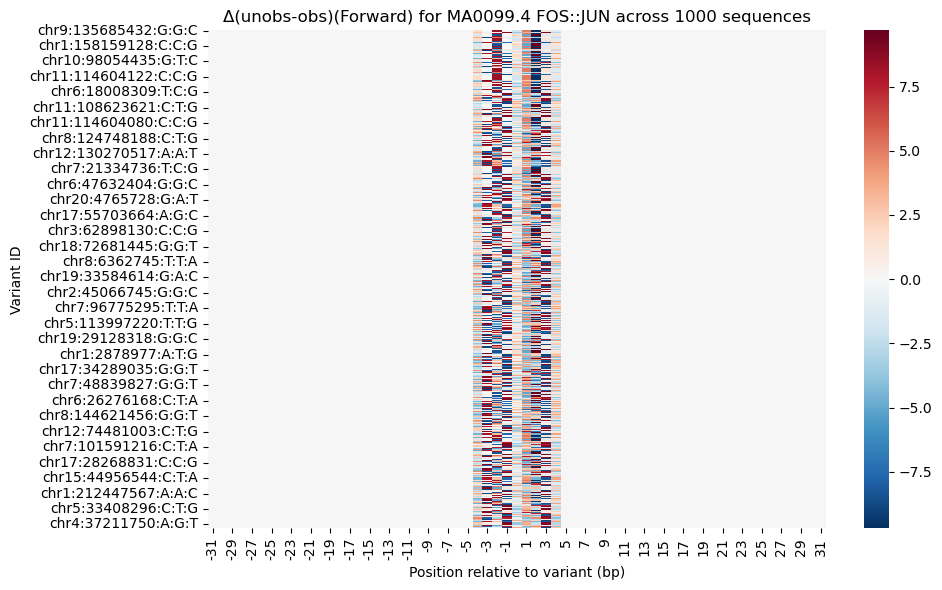

In [29]:
###
txt_motif_target = "MA0099.4 FOS::JUN"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["forward"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Forward) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


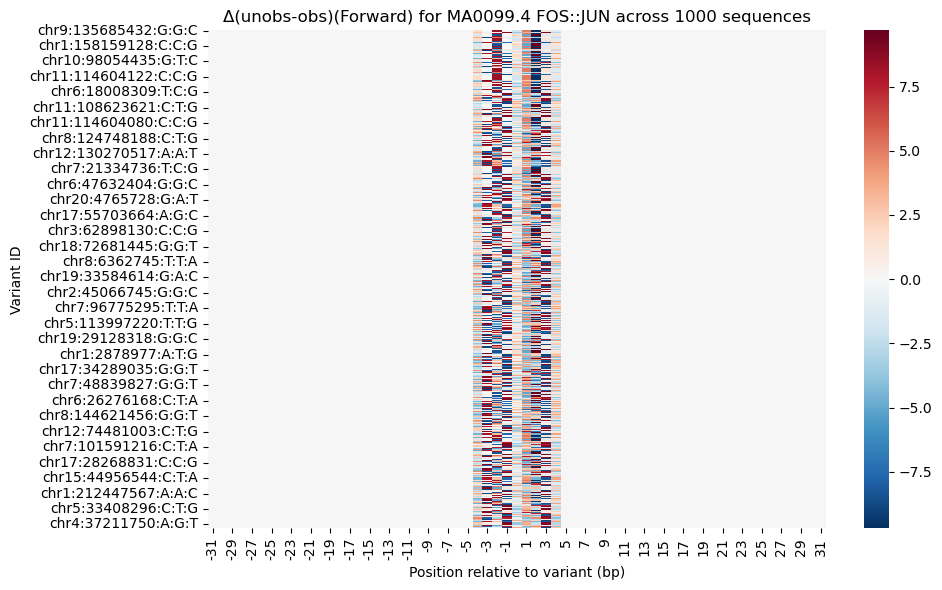

In [30]:
###
txt_motif_target = "MA0099.4 FOS::JUN"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["forward"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Forward) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


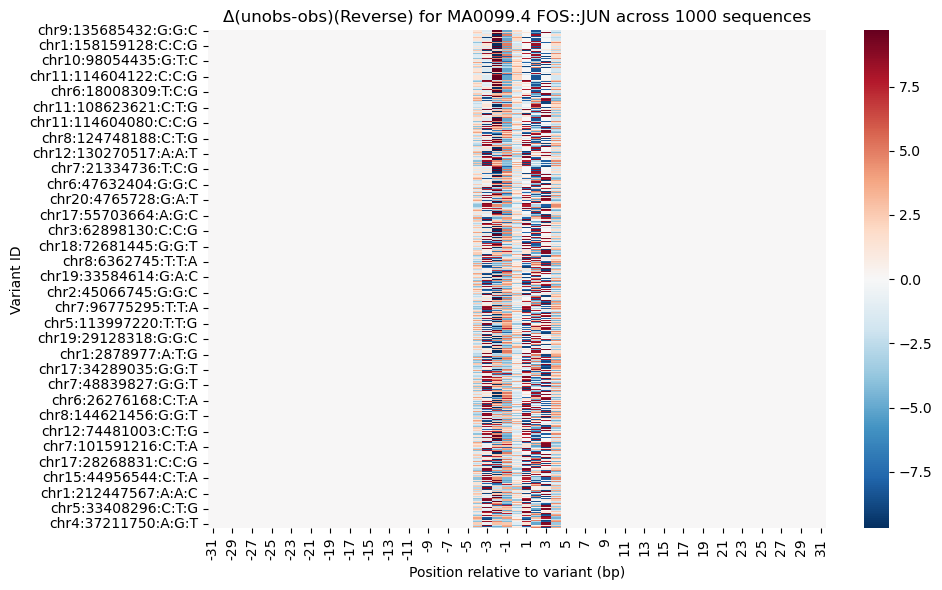

In [31]:
###
txt_motif_target = "MA0099.4 FOS::JUN"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["reverse"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Reverse) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


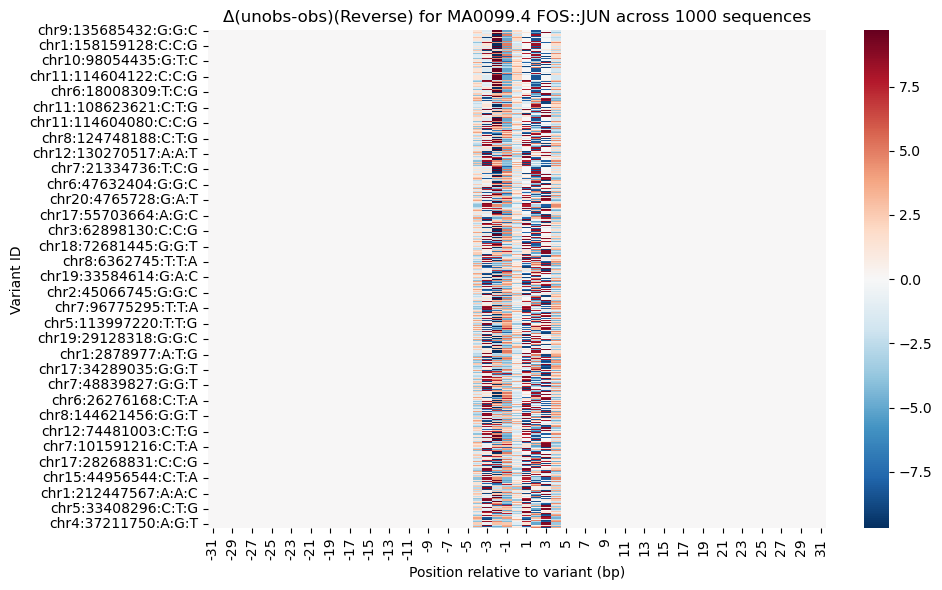

In [28]:
###
txt_motif_target = "MA0099.4 FOS::JUN"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["reverse"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Reverse) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

64 [-32 -31 -30 -29 -28] [27 28 29 30 31]


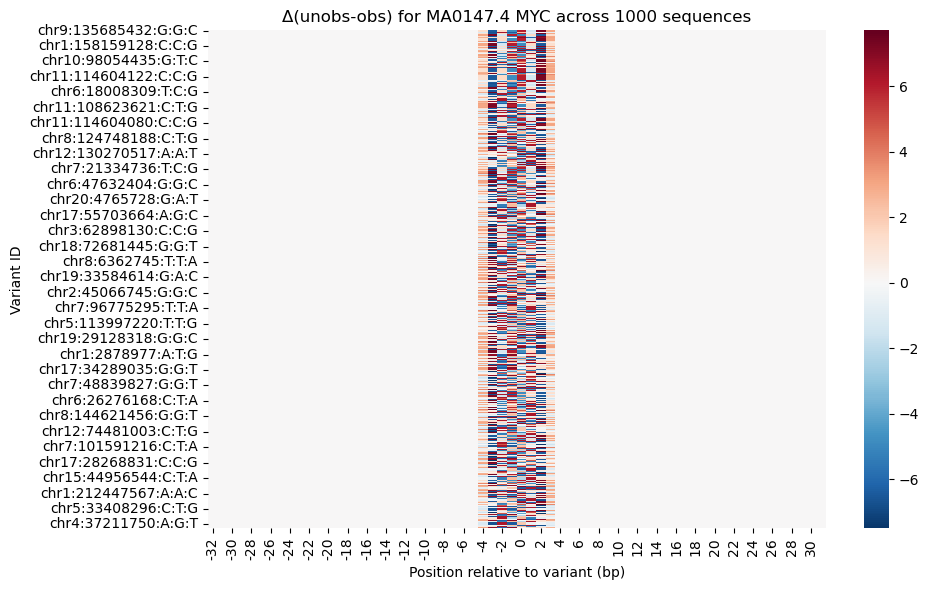

In [32]:
###
txt_motif_target = "MA0147.4 MYC"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["merge"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

64 [-32 -31 -30 -29 -28] [27 28 29 30 31]


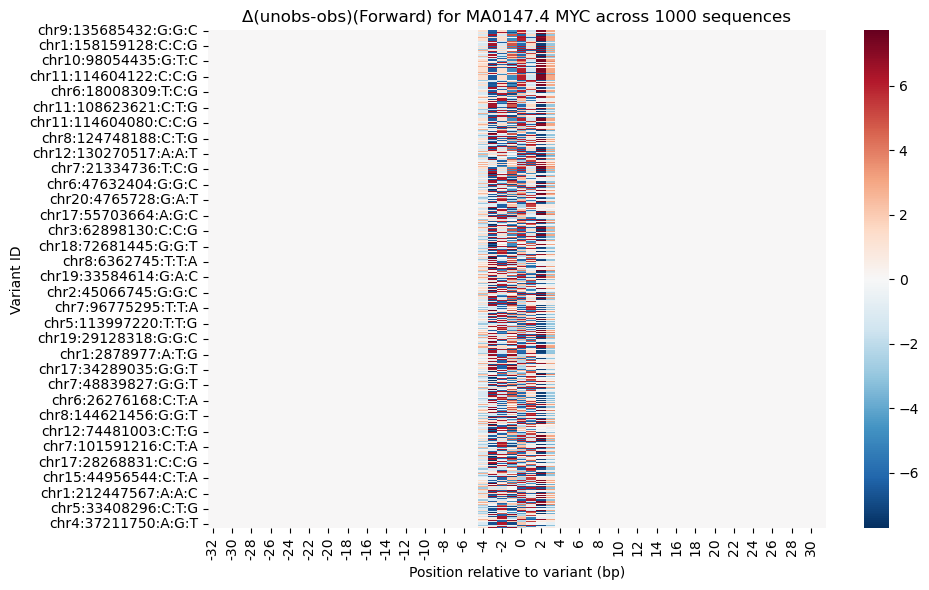

In [34]:
###
txt_motif_target = "MA0147.4 MYC"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["forward"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Forward) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

64 [-32 -31 -30 -29 -28] [27 28 29 30 31]


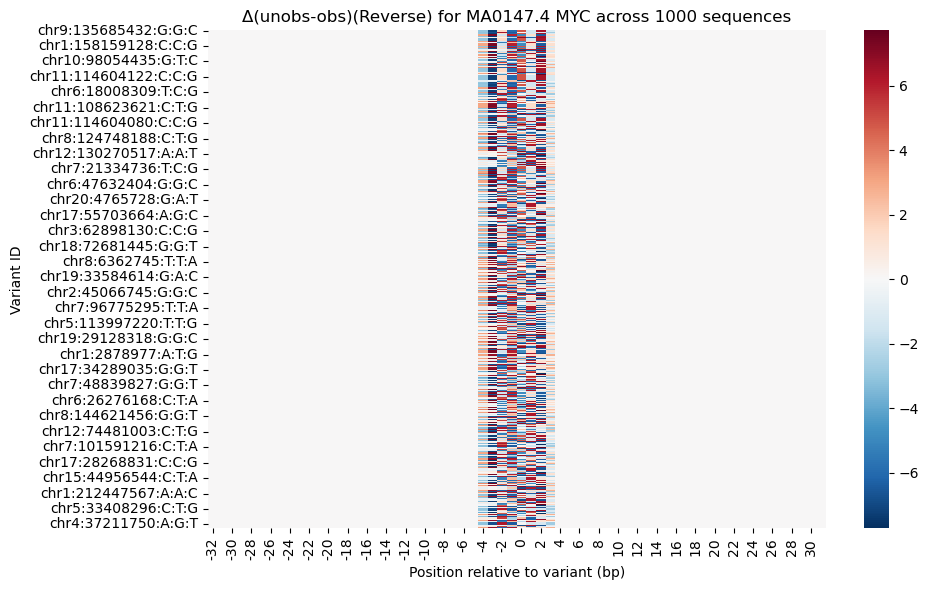

In [35]:
###
txt_motif_target = "MA0147.4 MYC"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["reverse"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Reverse) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

In [36]:
mat_motif_delta.shape

(1000, 64)

64 [-32 -31 -30 -29 -28] [27 28 29 30 31]


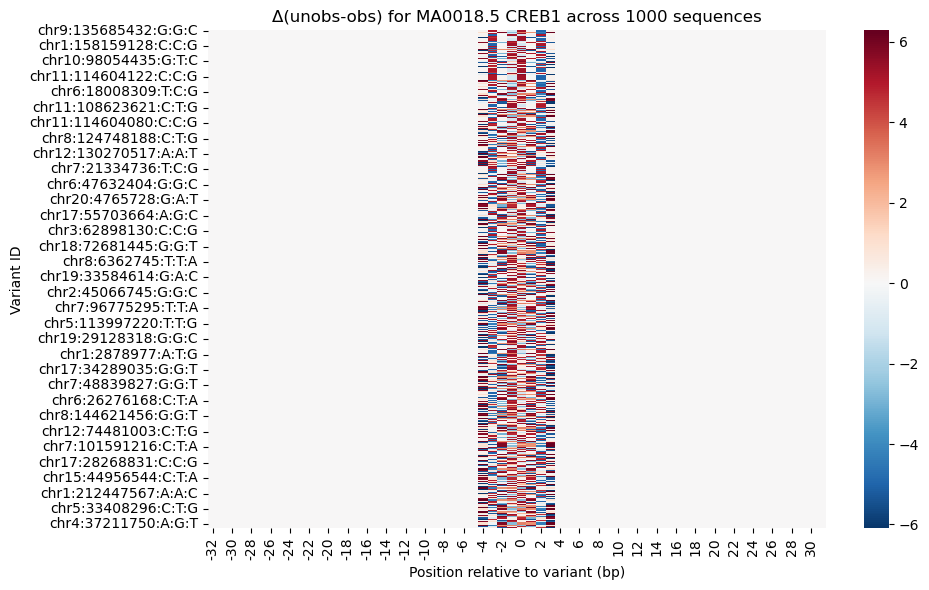

In [15]:
###
txt_motif_target = "MA0018.5 CREB1"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["merge"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


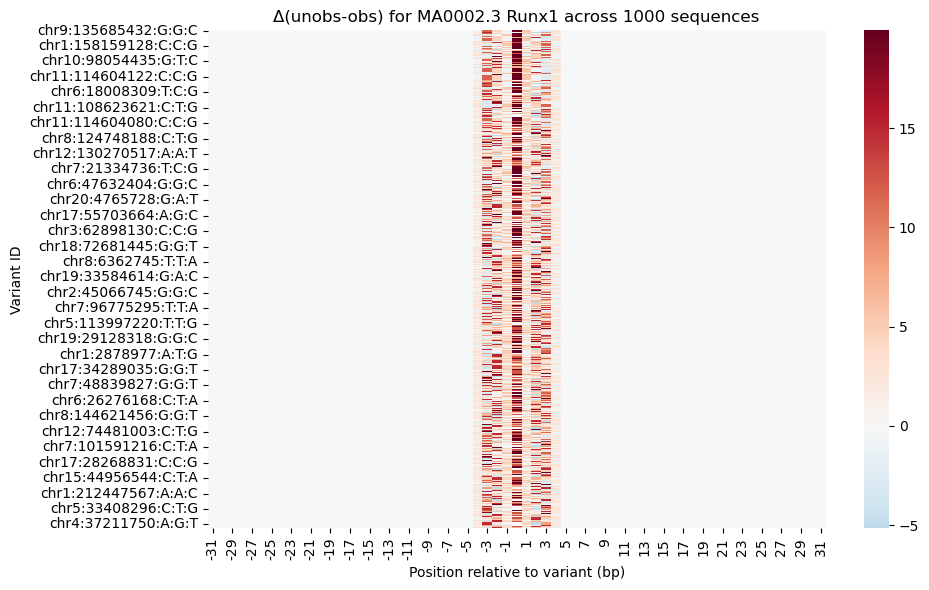

In [17]:
###
txt_motif_target = "MA0002.3 Runx1"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["merge"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


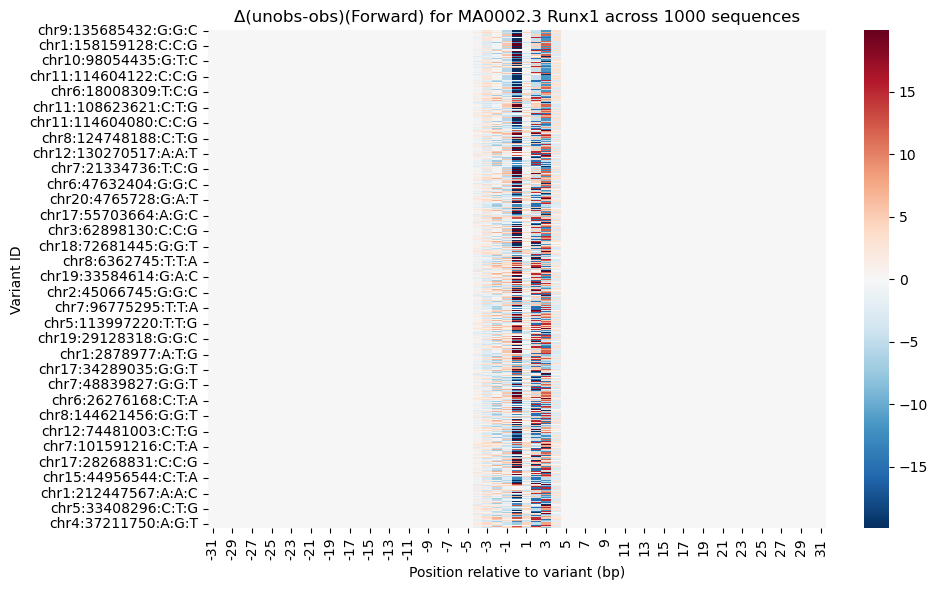

In [24]:
###
txt_motif_target = "MA0002.3 Runx1"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["forward"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Forward) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

63 [-31 -30 -29 -28 -27] [27 28 29 30 31]


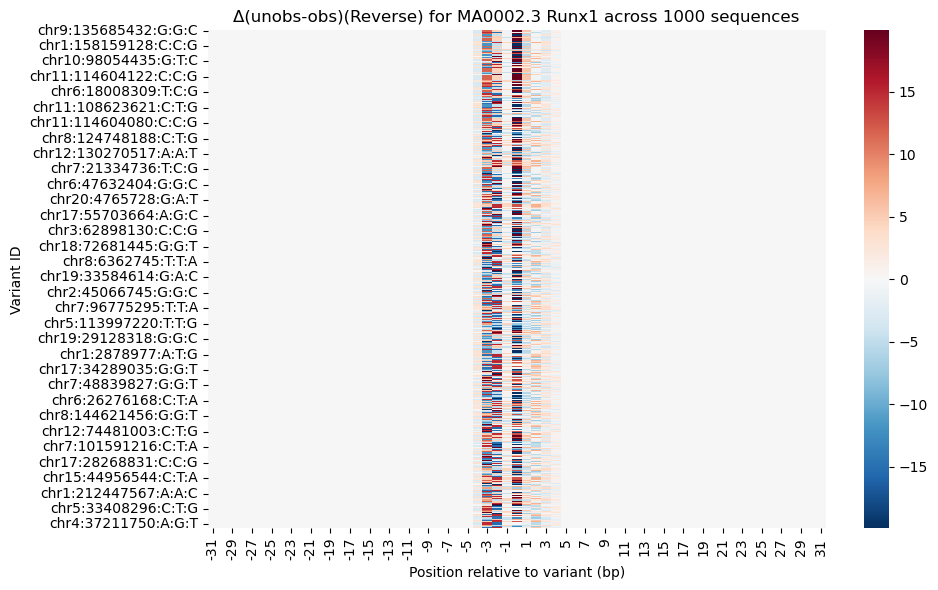

In [25]:
###
txt_motif_target = "MA0002.3 Runx1"

###
mat_motif_delta = np.vstack([
    dct_motifscan_delta[txt_seq_idx][txt_motif_target]["reverse"]
    for txt_seq_idx in dct_motifscan_delta.keys()
])

vec_txt_seq_idx = list(dct_motifscan_delta.keys())

###
num_motif_window = mat_motif_delta.shape[1]
num_half_length  = num_motif_window // 2  

if num_motif_window % 2 == 0:
    # even length: symmetric but no exact center
    vec_num_pos_label = np.arange(-num_half_length, num_half_length)
else:
    # odd length: centered at 0
    vec_num_pos_label = np.arange(-num_half_length, num_half_length + 1)
    
print(len(vec_num_pos_label), vec_num_pos_label[:5], vec_num_pos_label[-5:])

###
dat_motif_delta = pd.DataFrame(mat_motif_delta, index=vec_txt_seq_idx, columns=vec_num_pos_label)

plt.figure(figsize=(10,6))
sns.heatmap(dat_motif_delta, cmap="RdBu_r", center=0)
plt.title(f"Δ(unobs-obs)(Reverse) for {txt_motif_target} across 1000 sequences")
plt.xlabel("Position relative to variant (bp)")
plt.ylabel("Variant ID")
plt.tight_layout()
plt.show()

In [ ]:
sns.clustermap(
    dat_motif_delta, cmap="RdBu_r", center=0,
    row_cluster=True, col_cluster=False,
    figsize=(10,10))

In [27]:
print("Matrix shape:", dat_motif_delta.shape)
print("Number of rows with all NaN:", dat_motif_delta.isna().all(axis=1).sum())
print("Number of columns with all NaN:", dat_motif_delta.isna().all(axis=0).sum())

Matrix shape: (1000, 63)
Number of rows with all NaN: 0
Number of columns with all NaN: 0


/opt/conda/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


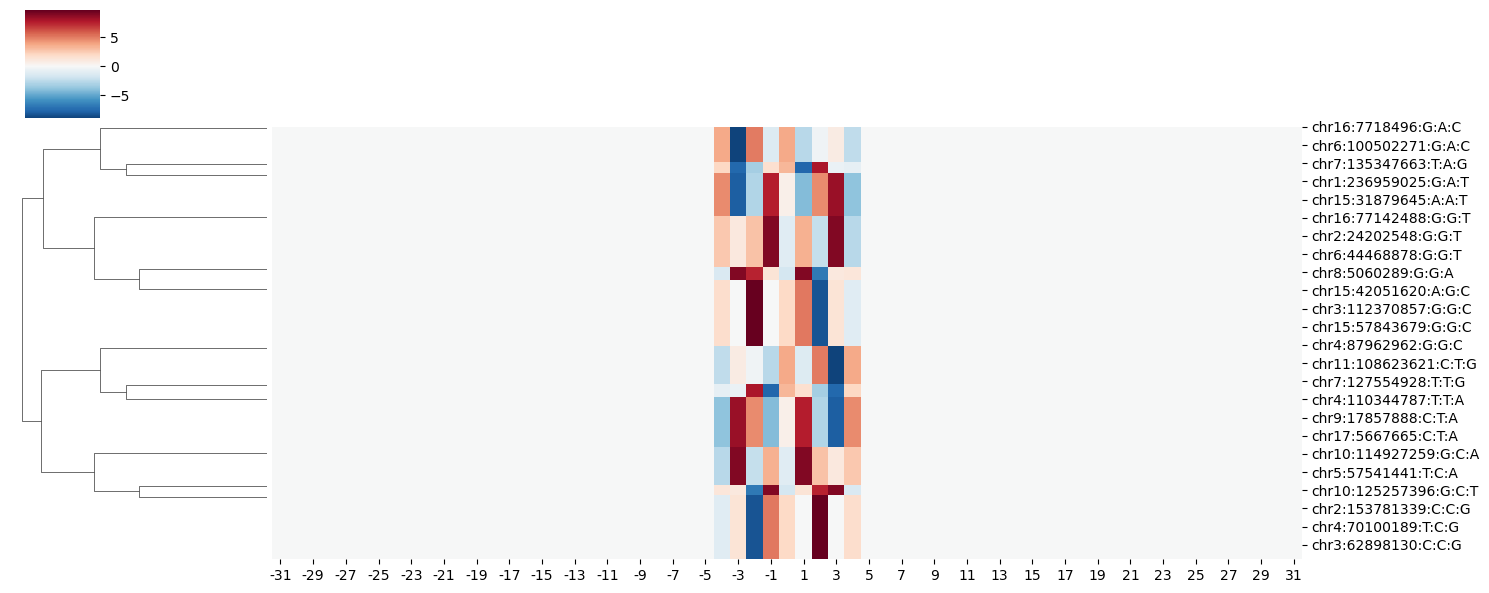

In [30]:
sns.clustermap(
    dat_motif_delta, cmap="RdBu_r", center=0,
    row_cluster=True, col_cluster=False,
    figsize=(15,6))